# 02 — Fourier-series convergence and the Gibbs phenomenon

Illustrates §3 of [`../FFT.md`](../FFT.md) — the historical disagreement between Fourier and Lagrange about whether discontinuous functions admit a trigonometric representation, and Dirichlet's resolution.

Two square-wave reconstructions are computed:

1. The Fourier series of a $2\pi$-periodic square wave, truncated at $N$ harmonics.
2. The Cesàro (arithmetic-mean) sum of the same series, which suppresses Gibbs ringing — Fejér's 1900 theorem.

References: Stein & Shakarchi (2003); Grattan-Guinness (1972).

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# A 2π-periodic square wave (odd extension of +1 on (0, π), -1 on (-π, 0))
# has Fourier series:  f(x) = (4/π) Σ_{k=0,1,2,...}  sin((2k+1)x) / (2k+1)

def square_wave(x):
    return np.sign(np.sin(x))

def fourier_partial_sum(x, N):
    """S_N(x) = (4/π) Σ_{k=0..N-1}  sin((2k+1)x) / (2k+1)."""
    k = np.arange(N)[:, None]                    # (N, 1)
    return (4.0/np.pi) * np.sum(np.sin((2*k + 1)*x) / (2*k + 1), axis=0)

def cesaro_sum(x, N):
    """σ_N(x) = (1/N) Σ_{m=1..N} S_m(x), the Cesàro average of the partial sums."""
    out = np.zeros_like(x)
    for m in range(1, N + 1):
        out += fourier_partial_sum(x, m)
    return out / N

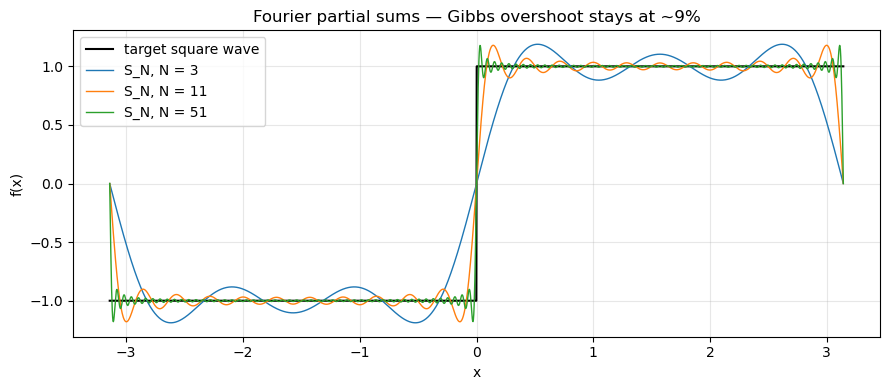

In [6]:
x = np.linspace(-np.pi, np.pi, 2000)
f = square_wave(x)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x, f, 'k', lw=1.5, label='target square wave')
for N in [3, 11, 51]:
    ax.plot(x, fourier_partial_sum(x, N), lw=1.0, label=f'S_N, N = {N}')
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.set_title('Fourier partial sums — Gibbs overshoot stays at ~9%')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Quantifying the overshoot

The classical result (Wilbraham, 1848; Gibbs, 1899) is that the maximum overshoot near a jump discontinuity converges to roughly **9% of the jump height** as $N \to \infty$ — it does *not* vanish. Demonstrate it numerically.

In [7]:
Ns = [5, 11, 21, 51, 101, 201, 501]
overshoots = []
for N in Ns:
    SN = fourier_partial_sum(x, N)
    overshoots.append(SN.max() - 1.0)            # jump amplitude is 2; max above target is the overshoot

for N, o in zip(Ns, overshoots):
    print(f'N = {N:4d} → overshoot = {o:.4f}  ({100*o/2:.2f}% of jump)')
print(f'\nGibbs constant 0.5*(2/π)*Si(π) - 0.5 ≈ {0.5*(2/np.pi*1.8519370519824662) - 0.5:.4f}')

N =    5 → overshoot = 0.1823  (9.12% of jump)
N =   11 → overshoot = 0.1797  (8.98% of jump)
N =   21 → overshoot = 0.1791  (8.95% of jump)
N =   51 → overshoot = 0.1786  (8.93% of jump)
N =  101 → overshoot = 0.1789  (8.94% of jump)
N =  201 → overshoot = 0.1790  (8.95% of jump)
N =  501 → overshoot = 0.1790  (8.95% of jump)

Gibbs constant 0.5*(2/π)*Si(π) - 0.5 ≈ 0.0895


The overshoot stabilises at the Wilbraham–Gibbs constant ≈ 0.0895 of the jump (≈ 9 %), confirming Stein & Shakarchi (2003, §2.3): the Fourier series of a discontinuous function does **not** converge uniformly near the discontinuity, even though it converges *pointwise* (Dirichlet, 1829) at every interior point.

## Cesàro averaging — Fejér's escape route

Fejér (1900) proved that the Cesàro means $\sigma_N = (S_1 + S_2 + \dots + S_N)/N$ of the partial sums converge **uniformly** to the function value wherever it is continuous, and to the average of left/right limits at jumps — *without* the Gibbs overshoot. This was the resolution that quietly closed the 19th-century controversy.

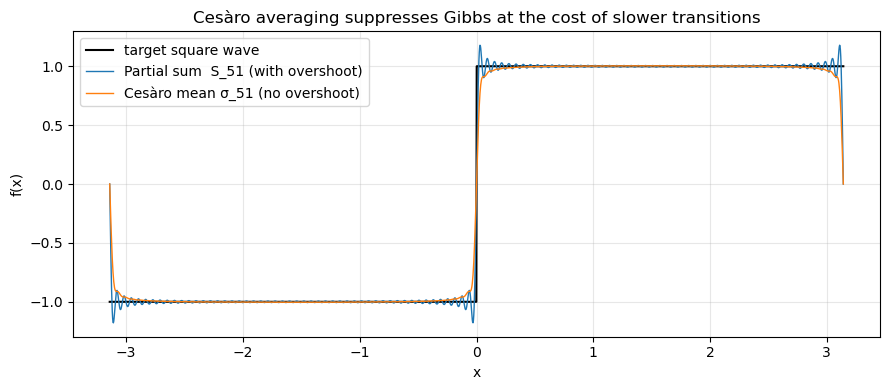

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x, f, 'k', lw=1.5, label='target square wave')
ax.plot(x, fourier_partial_sum(x, 51), lw=1.0, label='Partial sum  S_51 (with overshoot)')
ax.plot(x, cesaro_sum(x, 51), lw=1.0, label='Cesàro mean σ_51 (no overshoot)')
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.set_title('Cesàro averaging suppresses Gibbs at the cost of slower transitions')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Take-aways

- The Fourier partial sum of a discontinuous square wave **converges pointwise** to the function value at every continuity point (Dirichlet, 1829), but it **does not converge uniformly** — the 9 % overshoot near the jump persists at every truncation order.
- This is what made Lagrange (and then Cauchy) initially suspicious of Fourier's claim. The full resolution required (a) Dirichlet's pointwise theorem and (b) Fejér's uniform-convergence result via Cesàro means, half a century later.
- Practical lesson for spectral analysis: when a signal contains true discontinuities (square pulses, on/off events), low-order FFT-based reconstructions will show ringing artefacts. Window functions and Cesàro-style smoothing are the standard mitigations.